In [1]:
import sys
sys.path.append("../../src")
from common_imports import *
import kibble_zurek as kz
from kibble_zurek import P_n, sigma_general, state

In [30]:
L = 512
taus = np.logspace(-1,3,20)
states = [state(L,tau,tau) for tau in taus]

In [168]:
ns = np.arange(1,12+1)

In [169]:
Ps = []
for s in states:
    Ps.append( array([P_n(ni,s) for ni in ns]))

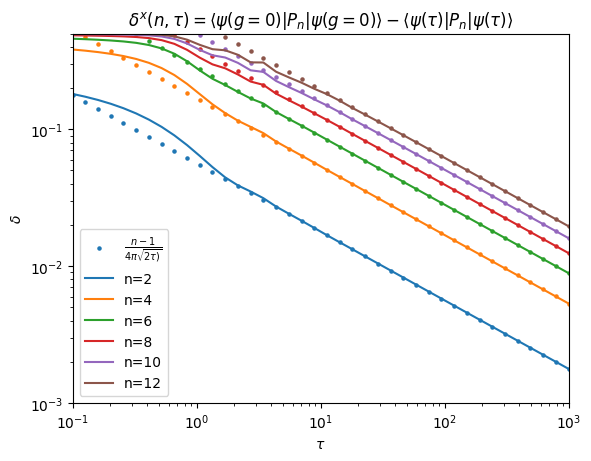

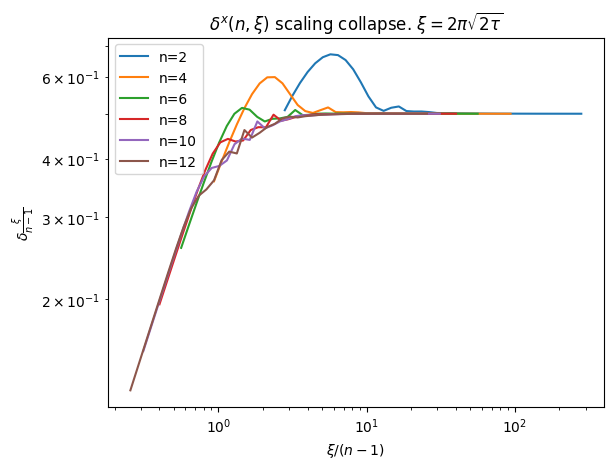

In [175]:
first = True
for n in ns[1::2]:

    defects = (n-1)/(4*pi*sqrt(2*taus))
    if first:
        scatter(taus, defects, s=5, label=r"$\frac{n-1}{4\pi \sqrt{2\tau)}}$")
        first = False
    else:
        scatter(taus, defects, s=5)
    plot(taus, abs(0.5 - array(Ps)[:, n-1]), label=f"n={n}")


ylim(0.001, .5)
xlim(taus[0], taus[-1])
title(r"$\delta^x(n,\tau)= \langle \psi(g=0)| P_n|\psi(g=0)\rangle-\langle \psi(\tau)|P_n|\psi(\tau) \rangle$")
legend()
xlabel(r"$\tau$")
ylabel(r"$\delta$")
loglog()
show()

for n in ns[1::2]:
    y = sqrt(taus)/(n-1)
    delta = abs(0.5 - array(Ps)[:, n-1])
    xi = 2*pi*sqrt(2*taus)

    plot(
        xi/(n-1),
        abs(delta * xi/(n-1)),
        label=f"n={n}"
    )
taus2= np.logspace(-3,3,20)
xi2 = 2*pi*sqrt(2*taus2)

xlabel(r"$\xi/(n-1)$")
ylabel(r"$\delta \frac{\xi}{n-1}$")
title(r"$\delta^x(n,\xi)$ scaling collapse. $\xi = 2 \pi \sqrt{2 \tau}$")
legend()
#plot(xi2,1/2-xi2**-2/10,"--k")
loglog()
show()


In [157]:
L = 512
taus = np.logspace(-1,3,40)
states = [state(L,tau,tau) for tau in taus]

In [158]:
import time_evolved_z_correlators as zz
Ps = []
ns=  np.arange(1,13)
for s in states:
    Ps.append( array([zz.P_n(ni,s) for ni in ns]))

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/defect_scaling_figures.ipynb/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


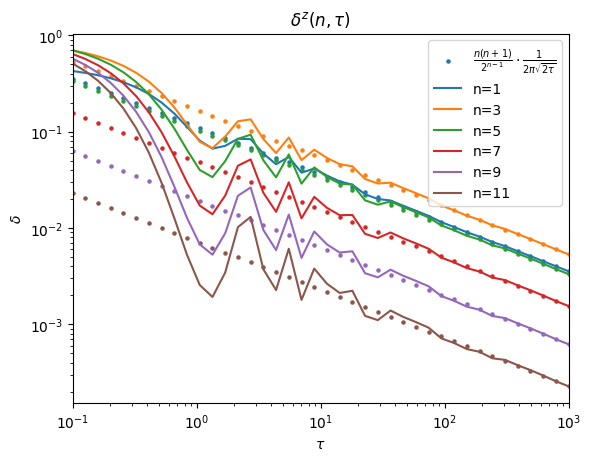

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9542/957972263.py:30: RuntimeWarning: divide by zero encountered in divide
  plot(xi/(n-1),scale,label=f"n={n}")


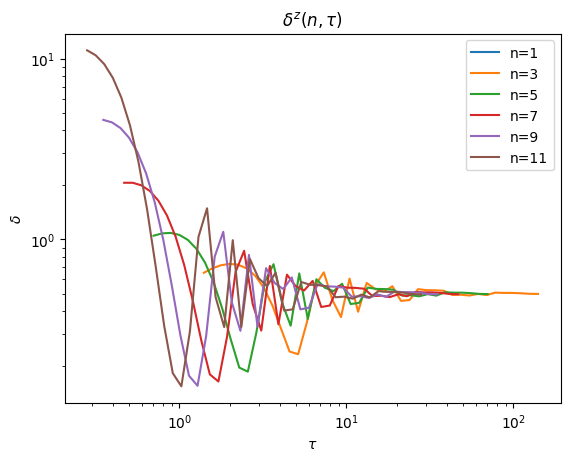

In [166]:
first = True
for n in ns[::2]:
    pf = n*(n+1)*2.**(-n-1)

    if first:
        scatter(taus,pf/sqrt(taus)/sqrt(2)/pi,s=5,label=r"$\frac{n(n+1)}{2^{n-1}} \cdot \frac{1}{2\pi \sqrt{2 \tau}}$" )
        first = False
    else:
        scatter(taus,pf/sqrt(taus)/sqrt(2)/pi,s=5 )
    

    plot(taus, abs(array(Ps)[:, n-1]-1/2**(n)), label=f"n={n}")

#ylim(0.01, .5)
xlim(taus[0], taus[-1])
title(r"$\delta^z (n,\tau)$")
legend()
xlabel(r"$\tau$")
ylabel(r"$\delta$")
loglog()
show()

first = True
xi = sqrt(2*taus)*2*pi
for n in ns[::2]:
    delta=  abs(array(Ps)[:, n-1]-1/2**(n))

    scale = 2**(n-1)*delta/n/(n+1)*xi
 #   plot(xi,scale)
    plot(xi/(n-1),scale,label=f"n={n}")
#xlim(xi[,xi[-1])
title(r"$\delta^z (n,\tau)$")
legend()
xlabel(r"$\tau$")
ylabel(r"$\delta$")
loglog()
show()
